# Unemployment Analysis with Python

## Table of Contents

1. Objective
2. Import Libraries
3. Load Dataset
4. Data Inspection
5. Data Cleaning
6. Data Type Conversion
7. Exploratory Data Analysis
   - Region-wise Analysis
   - Month-wise Trend
   - Time-Series Analysis
   - Top 10 States
   - Correlation Heatmap
8. Pre-COVID vs Post-COVID Analysis
9. Conclusion

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [10]:
# Load the dataset
df = pd.read_csv("Unemployment in India.csv")

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
# Check the shape of the dataset
df.shape

(768, 7)

In [12]:
# Display column names
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [13]:
# Get information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [14]:
# Check for missing values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [16]:
# Remove rows with missing values
df.dropna(inplace=True)

In [17]:
# Check missing values again
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [18]:
df.dtypes

Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

In [19]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

KeyError: 'Date'

In [20]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [21]:
# Remove leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

In [22]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [23]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [24]:
# Create Month and Year columns
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

In [25]:
df[['Date', 'Month', 'Year']].head()

,Date,Month,Year
0,2019-05-31,May,2019
1,2019-06-30,June,2019
2,2019-07-31,July,2019
3,2019-08-31,August,2019
4,2019-09-30,September,2019


### Data Type Conversion

The column names contained leading spaces, which were removed using `str.strip()`. The `Date` column was then converted from text (`object`) to the `datetime` data type. Finally, separate `Month` and `Year` columns were created to support time-based analysis and visualization.

In [26]:
# Calculate average unemployment rate by region
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

# Sort in descending order
region_avg = region_avg.sort_values(ascending=False)

# Display the result
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

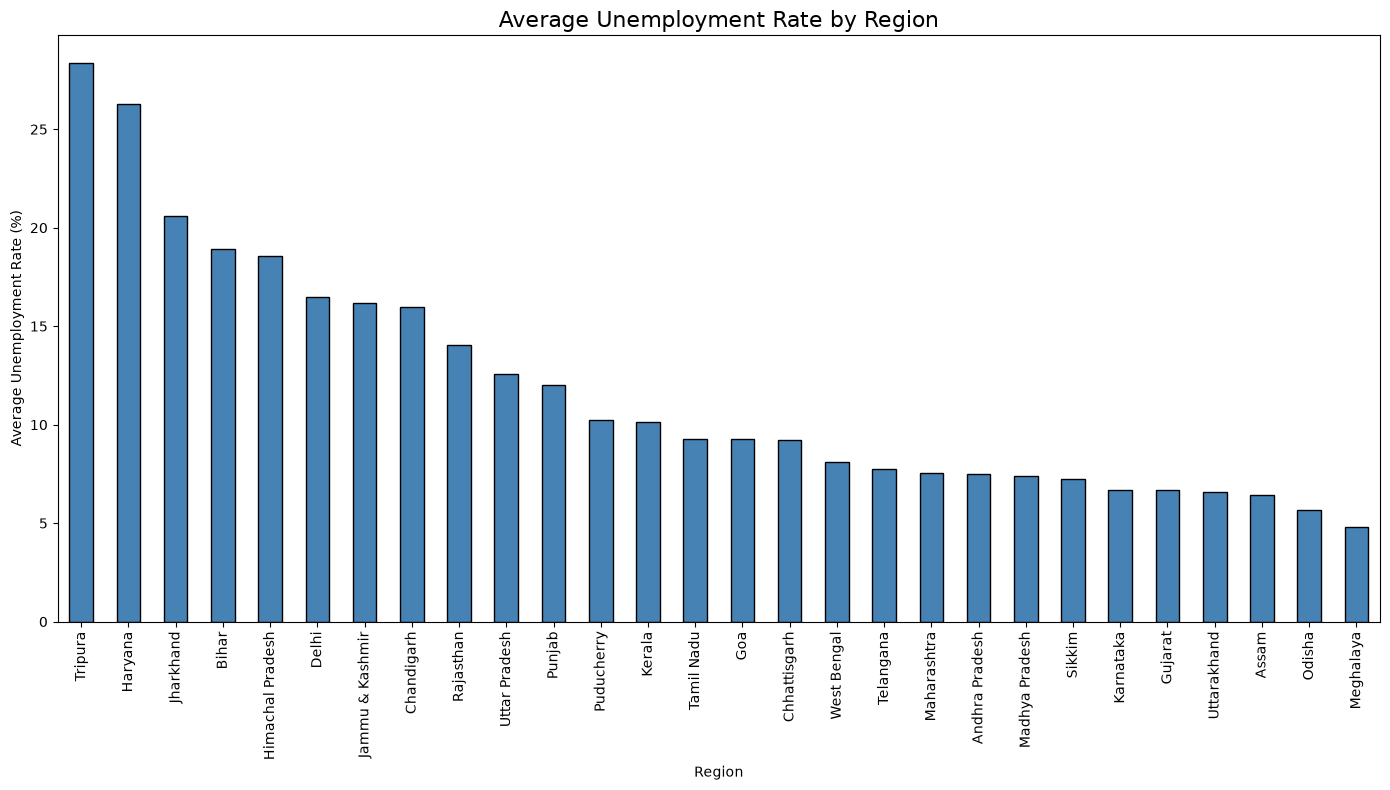

In [27]:
# Plot average unemployment rate by region

plt.figure(figsize=(14, 8))

region_avg.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Average Unemployment Rate by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Observation

The bar chart shows the average unemployment rate across different regions of India. Some regions experienced significantly higher unemployment than others, indicating regional differences in employment opportunities. These variations may be influenced by factors such as industrial development, economic activity, and the impact of the COVID-19 pandemic.

<Axes: ylabel='Region'>

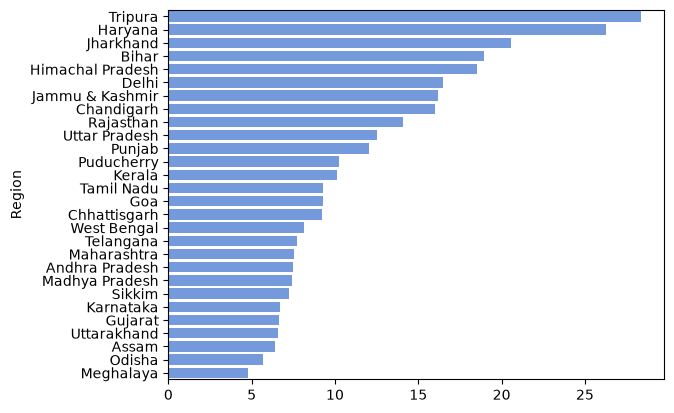

In [28]:
sns.barplot(x=region_avg.values, y=region_avg.index, color="cornflowerblue")

In [29]:
# Calculate average unemployment rate for each month

month_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

month_avg

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64

In [30]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

month_avg = month_avg.reindex(month_order)

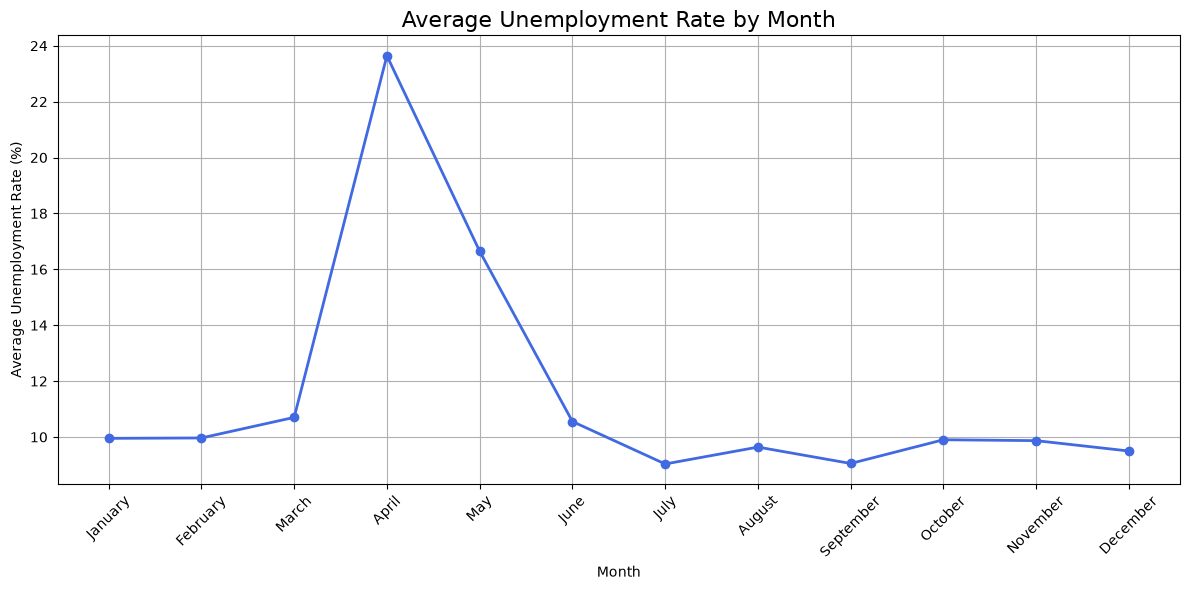

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    month_avg.index,
    month_avg.values,
    marker='o',
    linewidth=2,
    color='royalblue'
)

plt.title('Average Unemployment Rate by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

The line chart shows how the average unemployment rate changes across different months. A noticeable increase is observed during the COVID-19 lockdown period (around April–May 2020), followed by a gradual decline as economic activities resumed.

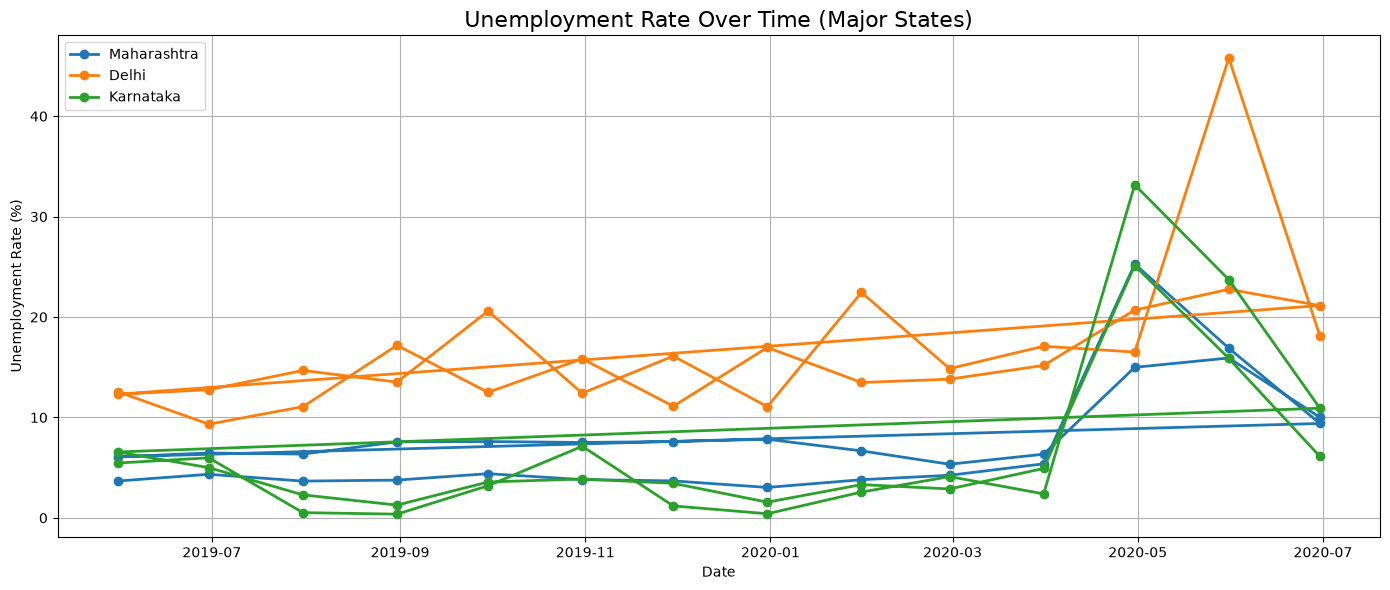

In [32]:
# Select three major states
states = ['Maharashtra', 'Delhi', 'Karnataka']

plt.figure(figsize=(14,6))

for state in states:
    state_data = df[df['Region'] == state]

    plt.plot(
        state_data['Date'],
        state_data['Estimated Unemployment Rate (%)'],
        marker='o',
        linewidth=2,
        label=state
    )

plt.title("Unemployment Rate Over Time (Major States)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The time-series chart compares unemployment trends in Maharashtra, Delhi, and Karnataka over time. All three states experienced a sharp increase in unemployment during the COVID-19 lockdown period. Delhi recorded the highest spike, while Maharashtra and Karnataka also showed noticeable increases before gradually recovering.

In [33]:
# Calculate average unemployment rate by region
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

# Sort in descending order and select top 10
top10 = top10.sort_values(ascending=False).head(10)

top10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

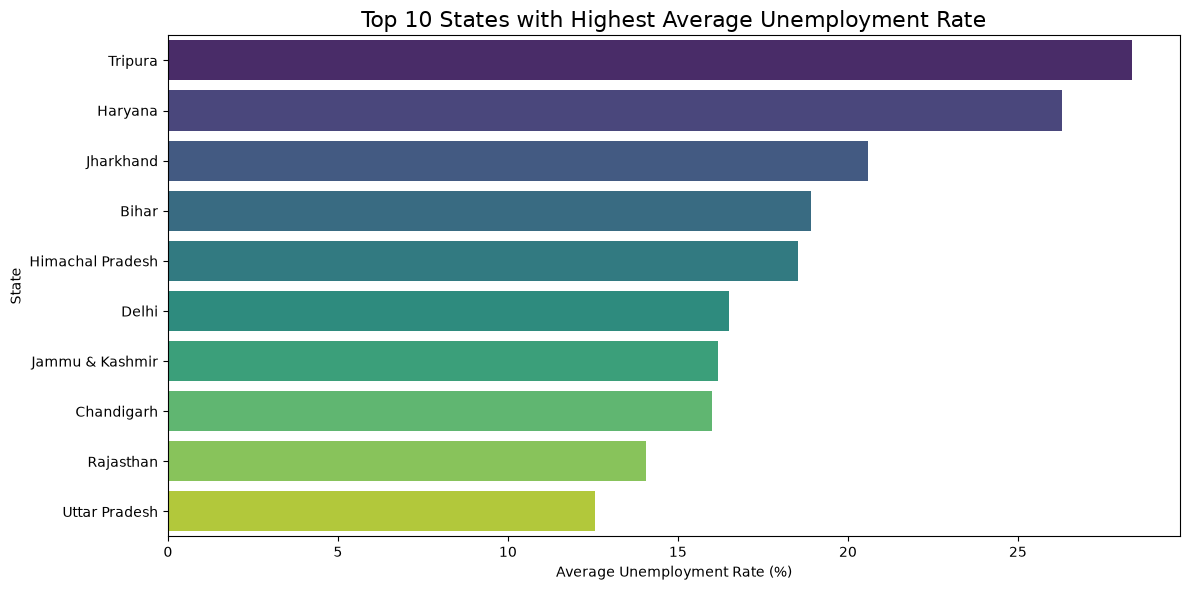

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 States with Highest Average Unemployment Rate', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

### Observation

The chart highlights the top 10 states with the highest average unemployment rates. Tripura recorded the highest average unemployment rate, followed by Haryana and Jharkhand. These states experienced comparatively greater employment challenges during the study period.

In [35]:
# Select numerical columns for correlation
corr = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

corr

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


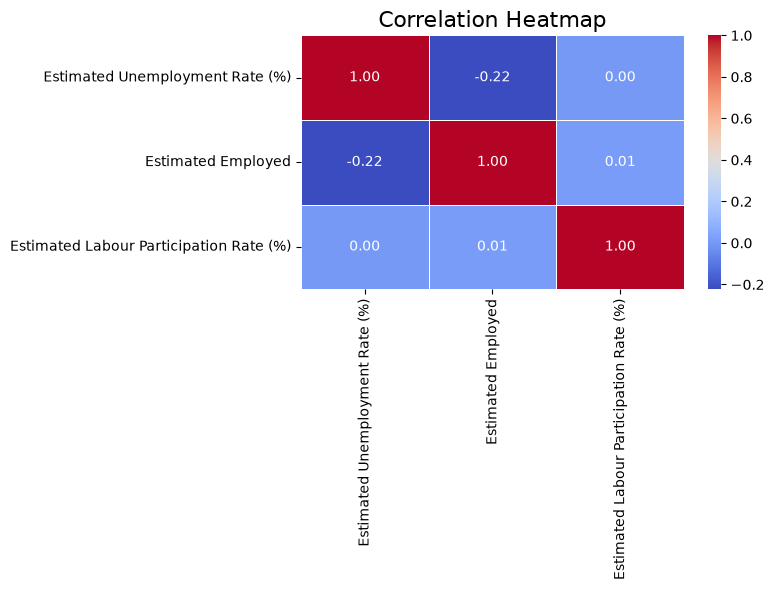

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

### Observation

The heatmap illustrates the correlation between unemployment rate, employment, and labour participation rate. The unemployment rate shows a negative correlation with the number of employed individuals, indicating that as employment increases, unemployment generally decreases. Labour participation rate has a moderate relationship with the other variables.

In [37]:
# Split dataset into pre-COVID and post-COVID periods

pre_covid = df[df['Date'] < '2020-03-24']
post_covid = df[df['Date'] >= '2020-03-24']

In [38]:
comparison = pd.DataFrame({
    'Period': ['Pre-COVID', 'Post-COVID'],
    'Average Unemployment Rate (%)': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        post_covid['Estimated Unemployment Rate (%)'].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%)
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


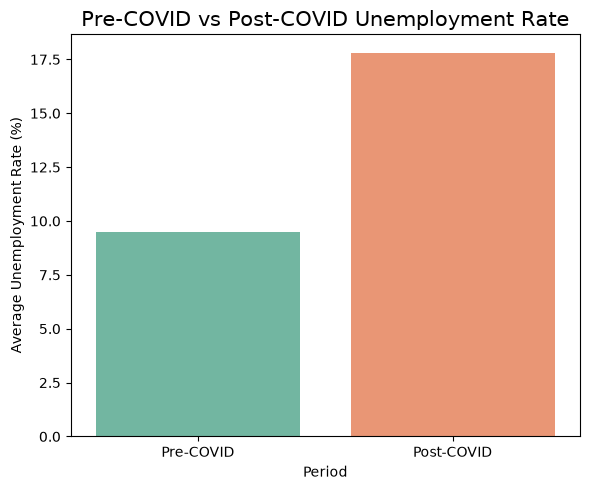

In [39]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x='Period',
    y='Average Unemployment Rate (%)',
    hue='Period',
    palette='Set2',
    legend=False
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate", fontsize=15)
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

### Observation

The comparison shows that the average unemployment rate increased significantly after the onset of the COVID-19 pandemic. The nationwide lockdown and economic slowdown resulted in a sharp rise in unemployment, highlighting the severe impact of COVID-19 on India's labour market.

# Conclusion

This project analyzed unemployment trends in India using Python, Pandas, Matplotlib, and Seaborn.

### Key Findings

- The dataset was cleaned by removing missing values and converting the Date column to datetime format.
- Significant regional differences in unemployment rates were observed, with Tripura, Haryana, and Jharkhand recording the highest average unemployment rates.
- Monthly trend analysis showed a sharp increase in unemployment during April and May 2020, reflecting the impact of the COVID-19 lockdown.
- The time-series analysis of Maharashtra, Delhi, and Karnataka demonstrated noticeable spikes in unemployment during the pandemic.
- Correlation analysis indicated that unemployment is negatively related to employment levels.
- The comparison between pre-COVID and post-COVID periods confirmed that unemployment increased substantially after the pandemic began.

Overall, the analysis highlights the significant impact of COVID-19 on employment across India and demonstrates how exploratory data analysis can uncover meaningful economic trends.